# Shape Detection 
by Eske and ELiot 




In [43]:
import Pkg
Pkg.activate("~/Detecting-Shapes")
Pkg.status()

Status `~/Slovenie/Topologie/Detecting-Shapes/~/Detecting-Shapes/Project.toml` (empty project)


  Activating new project at `~/Slovenie/Topologie/Detecting-Shapes/~/Detecting-Shapes`


In [44]:
# load all our functions etc 

# activate packages set environment 
using Pkg
Pkg.activate(".")
Pkg.instantiate()
Pkg.activate(".")
# include src files 
include("src/filtration.jl")
import .Filtration
include("src/preprocessing.jl")
import .Preprocessing
include("src/visualization.jl")
import .Visualization
include("src/persistence.jl")
import .Persistence


  Activating project at `~/Slovenie/Topologie/Detecting-Shapes`
  0 dependencies successfully precompiled in 3 seconds. 306 already precompiled.

The following 1 direct dependency failed to precompile:

DetectingShapes 

Error: Missing source file for Base.PkgId(Base.UUID("d4c3e3b0-7a3f-4f2b-9a5c-0f2b7e6a1234"), "DetectingShapes"  Activating project at `~/Slovenie/Topologie/Detecting-Shapes`


In [36]:
# add packages 
using Clustering
using StatsPlots
using LinearAlgebra
using PersistenceDiagrams
using Ripserer
using Plots

## Problem 
>Question: How can we distinguish/ detect different shapes? 

**What kind of shapes?**
Circle, Disk, Ellipsoid, Line Segment, Potato, Sphere, Torus ... 

- need pointclouds to display them in the computer 
- pointclouds should be in some sense normalized 

In [47]:
# Load pointclouds 
shapes = ["sphere", "torus", "line_segment", "disk", "potato", "ellipsoid"]
n_pershape = [1,2,3,4,5]
n_datapoints = 250

# some other less important settings 
path_changes = Dict("line_segment" => "line")
good_layout = (3,2)

# vector saving the loaded pointclouds 
pointclouds = []

# vector indicating to which shape each pointcloud belongs to 
corr_results = []

# load the pointclouds from the data
for s in shapes
    for i in n_pershape
        push!(corr_results, s * "_" * lpad(i, 4, '0'))

        # build filename (handle special cases)
        base = haskey(path_changes, s) ? path_changes[s] : s
        fname = string(base, "_", lpad(i, 4, '0'), ".csv")

        # build path (portable)
        path = joinpath("data", s, "samples", fname)

        println(path)

        df = Preprocessing.load_pointcloud_csv(path)

        if n_datapoints != "end"
            df = df[1:n_datapoints, :]
        end

        push!(pointclouds, df)
    end
end


data/sphere/samples/sphere_0001.csv
data/sphere/samples/sphere_0002.csv
data/sphere/samples/sphere_0003.csv
data/sphere/samples/sphere_0004.csv
data/sphere/samples/sphere_0005.csv
data/torus/samples/torus_0001.csv
data/torus/samples/torus_0002.csv
data/torus/samples/torus_0003.csv
data/torus/samples/torus_0004.csv
data/torus/samples/torus_0005.csv
data/line_segment/samples/line_0001.csv
data/line_segment/samples/line_0002.csv
data/line_segment/samples/line_0003.csv
data/line_segment/samples/line_0004.csv
data/line_segment/samples/line_0005.csv
data/disk/samples/disk_0001.csv
data/disk/samples/disk_0002.csv
data/disk/samples/disk_0003.csv
data/disk/samples/disk_0004.csv
data/disk/samples/disk_0005.csv
data/potato/samples/potato_0001.csv
data/potato/samples/potato_0002.csv
data/potato/samples/potato_0003.csv
data/potato/samples/potato_0004.csv
data/potato/samples/potato_0005.csv
data/ellipsoid/samples/ellipsoid_0001.csv
data/ellipsoid/samples/ellipsoid_0002.csv
data/ellipsoid/samples/ell

In [84]:
# Display first 10 points of the first pointcloud
pointclouds[1][1:10,:]

10×1 Matrix{Tuple{Float64, Float64, Float64}}:
 (0.420097290272755, 0.3449117871735559, -0.6950992375440218)
 (0.2573280770970832, 0.5024578206142405, -0.6912173725443743)
 (-0.5943966009427398, 0.5013764735062565, 0.6182811278213052)
 (-0.013050566119509558, 0.028820915283268658, -0.8893551050031366)
 (0.4736840534066516, 0.779887950050544, -0.03470003388263748)
 (0.3501452742229558, -0.842166096237337, 0.10331210144708688)
 (0.17975952612800303, -0.20325051325356536, -0.8431167645377321)
 (-0.4776803696000899, -0.7683121932364436, -0.16774159292631696)
 (0.6121379610921235, -0.5395321252272214, 0.45602905848858694)
 (-0.8093115942694452, 0.3883279317112105, 0.36997801636823385)

In [49]:
# center and normalize the pointclouds
for (i, S) in enumerate(pointclouds)
    S = Preprocessing.center_points(S)
    S = Preprocessing.normalize_scale(S) 
    # change the format from matrix to [(x1, y1, z1), (x2, y2,z2), ...]
    pointclouds[i] = [tuple(S[i, :]...) for i in axes(S, 1)]
end

In [50]:
pointclouds[1][1:10,:]

10×1 Matrix{Tuple{Float64, Float64, Float64}}:
 (0.420097290272755, 0.3449117871735559, -0.6950992375440218)
 (0.2573280770970832, 0.5024578206142405, -0.6912173725443743)
 (-0.5943966009427398, 0.5013764735062565, 0.6182811278213052)
 (-0.013050566119509558, 0.028820915283268658, -0.8893551050031366)
 (0.4736840534066516, 0.779887950050544, -0.03470003388263748)
 (0.3501452742229558, -0.842166096237337, 0.10331210144708688)
 (0.17975952612800303, -0.20325051325356536, -0.8431167645377321)
 (-0.4776803696000899, -0.7683121932364436, -0.16774159292631696)
 (0.6121379610921235, -0.5395321252272214, 0.45602905848858694)
 (-0.8093115942694452, 0.3883279317112105, 0.36997801636823385)

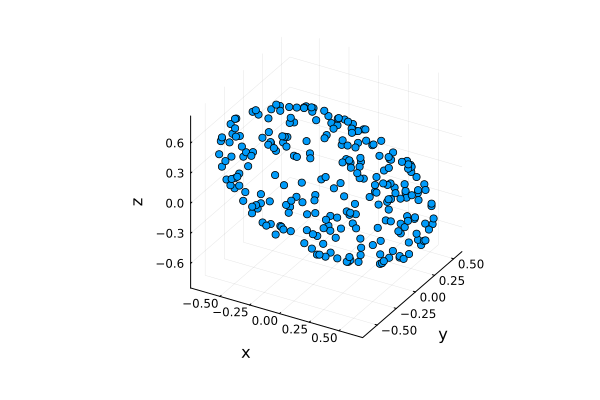

In [51]:
# visualize point cloud 
name = "ellipsoid_0001"
if !(name in corr_results)
    println("change the name to a loaded pointlcoud")
    println("- possible shapes: ", shapes)
    println("- possible numbers: ", n_pershape)
    println("name should be shape_00xx with xx changed to number")
else 
    idx = findfirst( ==(name), corr_results)
    display(Visualization.plot_pointcloud_3d(pointclouds[idx], check_npoints = false))
end 

>Question: How can we distinguish/ detect different shapes? 

**What kind of shapes?** 

        pointclouds ✔

**How to approximate the shapes in the computer?** 

- Some of the shapes are homotopy equivalent (Disk, Line, Potato are contractible, Ellipsoid h.e. to sphere)
- use persistent homology 
- need filtrations 
    - ~~Rips or Cech filtration~~ --> *very slow* :(
- use **Ripserer** to directly compute the persistence diagrams 
    `result = ripserer(S; dim_max = dim-1)`

In [52]:
# "Ripserer" indicates which filtration to use, false just avoids some print output
diagrams = Persistence.create_persistence_diagram(pointclouds, "Ripserer", false)

30-element Vector{Any}:
 PersistenceDiagram[250-element 0-dimensional PersistenceDiagram, 73-element 1-dimensional PersistenceDiagram, 1-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[250-element 0-dimensional PersistenceDiagram, 68-element 1-dimensional PersistenceDiagram, 1-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[250-element 0-dimensional PersistenceDiagram, 65-element 1-dimensional PersistenceDiagram, 1-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[250-element 0-dimensional PersistenceDiagram, 69-element 1-dimensional PersistenceDiagram, 3-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[250-element 0-dimensional PersistenceDiagram, 68-element 1-dimensional PersistenceDiagram, 2-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[250-element 0-dimensional PersistenceDiagram, 68-element 1-dimensional PersistenceDiagram, 38-element 2-dimensional PersistenceDiagram]
 PersistenceDiagram[250-element 0-dimensional

For each pointlcoud, we have now three persistence diagrams, one for each dimension


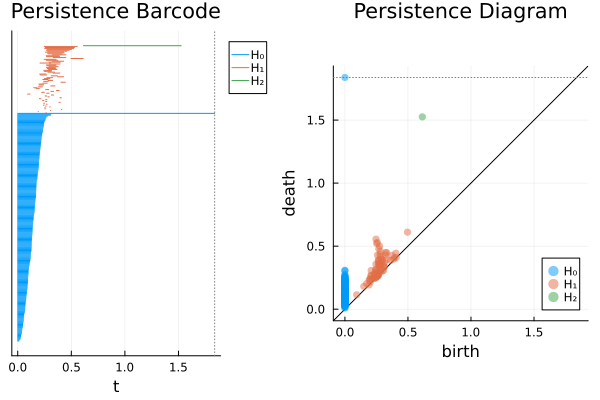

In [53]:
println("For each pointlcoud, we have now three persistence diagrams, one for each dimension")
diagrams[1]
display(plot( barcode(diagrams[1]), plot(diagrams[1])))

>Question: How can we distinguish/ detect different shapes? 

**What kind of shapes?** 

        pointclouds ✔

**How to approximate the shapes in the computer?** 
        
        Ripserer to compute persistence Diagrams ✔

**How to classify the different diagrams?** 

- Need some clustering on the diagrams
    - **Idea 1)** Use the Wasserstein distance on the persistence diagrams directly to perform clustering 
    - **Idea 2)** Convert the diagrams in a more useful datastructure and then perform clustering 

### The Wasserstein distance

The Wasserstein distance can be interpreted as the minimal amount of "work" required to transform one persistence diagram into another.

- Each point in a persistence diagram represents a topological feature with a birth and a death time.
- Moving a point in the diagram has a cost proportional to the Euclidean distance between its original and final positions.
- If a feature has no counterpart in the other diagram, it is matched to the diagonal, which corresponds to removing or creating that feature.
- The optimal matching is the one that minimizes the total transportation cost.

As a result, diagrams with similar topological structures have a small Wasserstein distance, while diagrams corresponding to different shapes yield larger distances.



In [54]:
# compute the distance matrix for each dimension 
Ds = Persistence.create_wasserstein_matrix(diagrams)

3-element Vector{Matrix{Float64}}:
 [0.0 1.9566414795111315 … 9.318257036419473 8.374783870488342; 1.9566414795111315 0.0 … 7.676748577641663 6.751795089149086; … ; 9.318257036419473 7.676748577641663 … 0.0 1.2797677632733855; 8.374783870488342 6.751795089149086 … 1.2797677632733855 0.0]
 [0.0 1.2732968424594229 … 2.286283385930562 2.3019178222957004; 1.2732968424594229 0.0 … 2.1668477386999245 2.0905001900052977; … ; 2.286283385930562 2.1668477386999245 … 0.0 0.6940013851995785; 2.3019178222957004 2.0905001900052977 … 0.6940013851995785 0.0]
 [0.0 0.039859144245104394 … 0.617169274158951 0.5912963012714113; 0.039859144245104394 0.0 … 0.5773101299138466 0.5514371570263069; … ; 0.617169274158951 0.5773101299138466 … 0.0 0.025872972887539647; 0.5912963012714113 0.5514371570263069 … 0.025872972887539647 0.0]

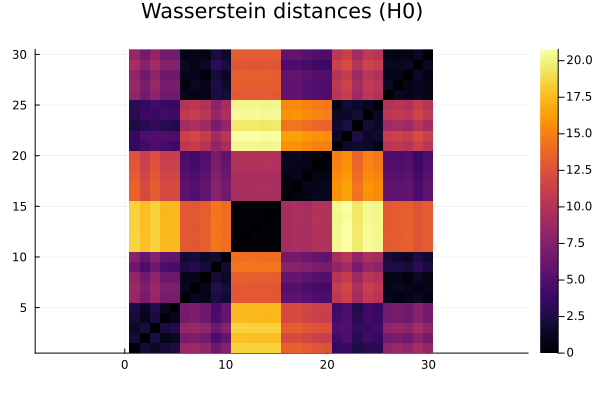

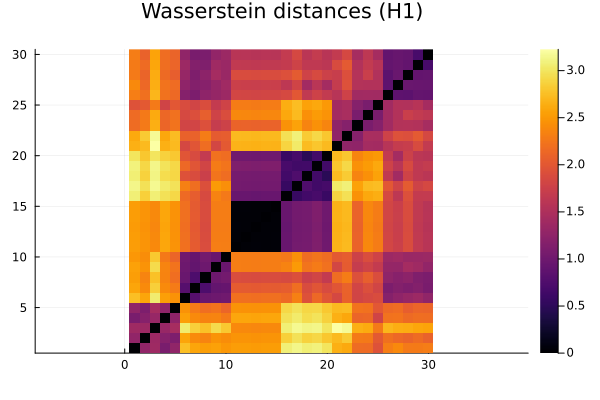

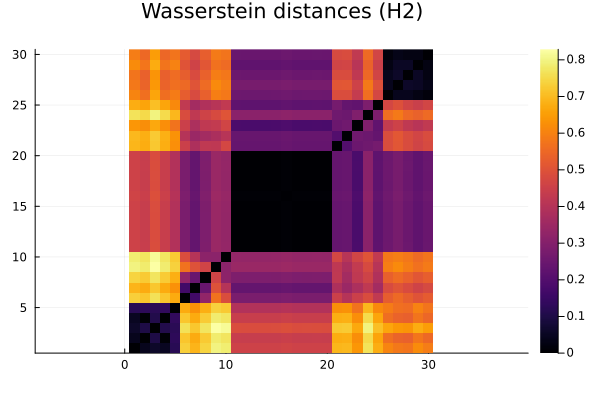

In [57]:
display(heatmap(Ds[1], aspect_ratio=:equal, title="Wasserstein distances (H0)"))
display(heatmap(Ds[2], aspect_ratio=:equal, title="Wasserstein distances (H1)"))
display(heatmap(Ds[3], aspect_ratio=:equal, title="Wasserstein distances (H2)"))

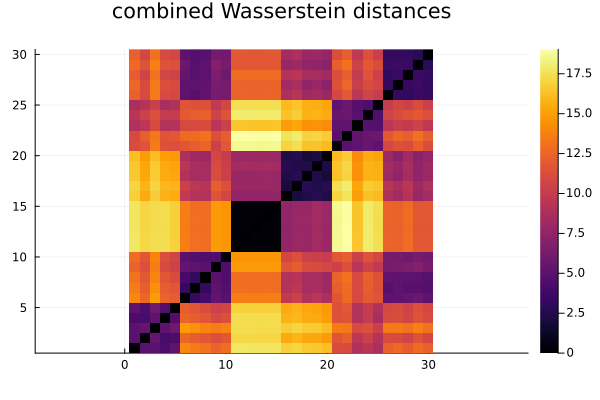

In [62]:
# combine the different distance matrices 
weights = (0.5,3, 2.0)

n = size(Ds[1], 1)
# empty matrix of same size 
D = zeros(Float64, n, n)

# combine the different distance matrices using the weights 
for (hi, w) in enumerate(weights)
    D += w .* Ds[hi]
end 
display(heatmap(D, aspect_ratio=:equal, title="combined Wasserstein distances"))

In [63]:
# clustering 

results_clustering = hclust(D; linkage=:average)
clusters = cutree(results_clustering; k = length(shapes))

for c in 1:length(shapes)
    println("Cluster $c ---------")
    println(corr_results[clusters.== c])
end


Cluster 1 ---------
Any["sphere_0001", "sphere_0002", "sphere_0003", "sphere_0004", "sphere_0005"]
Cluster 2 ---------
Any["torus_0001", "torus_0002", "torus_0003", "torus_0004", "torus_0005"]
Cluster 3 ---------
Any["line_segment_0001", "line_segment_0002", "line_segment_0003", "line_segment_0004", "line_segment_0005"]
Cluster 4 ---------
Any["disk_0001", "disk_0002", "disk_0003", "disk_0004", "disk_0005"]
Cluster 5 ---------
Any["potato_0001", "potato_0002", "potato_0003", "potato_0004", "potato_0005"]
Cluster 6 ---------
Any["ellipsoid_0001", "ellipsoid_0002", "ellipsoid_0003", "ellipsoid_0004", "ellipsoid_0005"]


### Persistence Silhuette 

persistence silhuette **summaries** the information of the persistence diagrams 

**Persistence diagram** →transformed to→     real valued function i.e. a **vector** = persistence silhuette

For each bar $[b_i, d_i)$ in the persistence diagram, we compute a weight 
$$ w_i := |d_i - b_i| $$
And a triangle function 
$$\Lambda_i(t) := \begin{cases} t-b & t \in [b, \frac{b+d}{2}) \\ d-t & t \in (\frac{b+d}{2}, d] \end{cases} $$
This combines in the silhoutte function 
$$\phi_i(t) := \frac{\sum_i w_i \Lambda_i}{\sum_i w_i}$$

>"Stochastic Convergence of Persistence Landscapes and Silhouettes", Chazal F. et al

1) Compute persistence silhuette for each dimension and pointcloud
2) For each pointcloud concatenate the silhuette functions 
3) Perform clustering on the obtaines vectors 
    - kmean
    - hclust

In [64]:
silhouettes_separatly = [[Persistence.persistence_silhoutte(d) for d in diags] for diags in diagrams] 

30-element Vector{Vector{Vector{Float64}}}:
 [[0.0, 0.0031172351006058443, 0.006233644856214412, 0.009347063920560991, 0.012457963739274337, 0.015554173552591406, 0.01863371757266319, 0.021678990747868557, 0.024692242737847994, 0.027656854193061697  …  0.0004539021378996896, 0.0003987022311536497, 0.00034350232440760986, 0.00028830241766157, 0.0002331025109155301, 0.00017790260416949028, 0.00012270269742345138, 6.750279067741153e-5, 2.7820088788181283e-5, 0.0], [0.0, 2.2062051322343968e-5, 4.4124102644687874e-5, 2.2598484092779873e-5, 5.364327704359057e-7, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.001079858560010067, 0.0009598742755645046, 0.0008398899911189397, 0.0007199057066733771, 0.0005999214222278148, 0.0004799371377822523, 0.00035995285333668986, 0.00023996856889112484, 0.00011998428444556242, 0.0], [0.0, 0.009203633101149467, 0.018407266202298933, 0.02761089930344829, 0.036814532404597755, 0.04601816550574722, 0.05522179860689669, 0.06442543170804615, 0.07362906480919562, 0.082832697910344

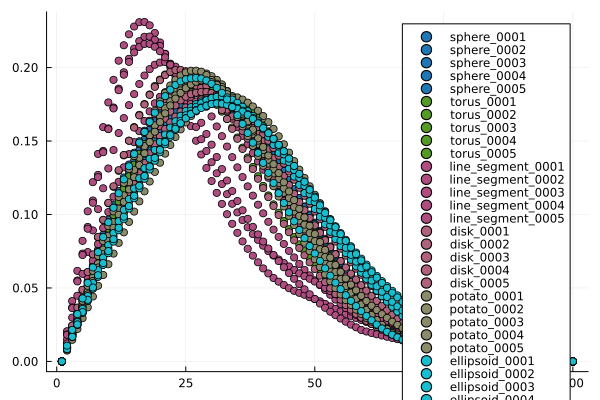

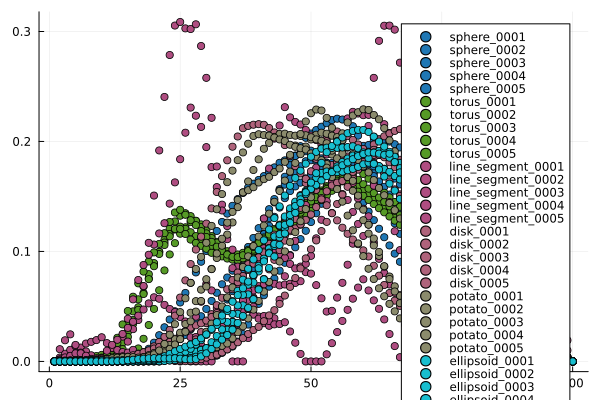

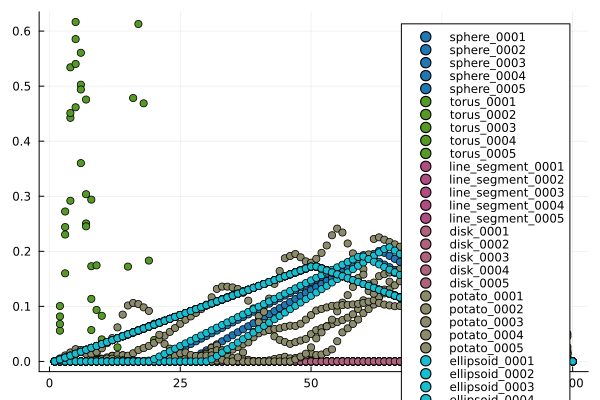

In [65]:
# plot all persistence silhouettes together coloured by their shape 
shape_colors = palette(:tab10, length(shapes)) 

plots = []
for i in 1:length(silhouettes_separatly[1])
    pl = plot()
    for sil_idx in 1:length(corr_results)
        sil = silhouettes_separatly[sil_idx][i]
        
        # normalize
        if norm(sil) != 0 
            sil = sil ./ norm(sil)
        end

        # shape of the pointcloud
        sp = join(split(corr_results[sil_idx], "_")[1:end-1], "_")
        
        # get index of the shape in shapes 
        sp_idx =  findfirst( ==(sp), shapes)
        scatter!(pl, 1:length(sil), sil; color = shape_colors[sp_idx],label= corr_results[sil_idx])
    end 
    push!(plots, pl)
end 

for pl in plots
    display(pl)
end 


In [68]:
include("src/persistence.jl")
import .Persistence

In [69]:
weights = (0.1,0.45, 0.45)
silhouettes = [Persistence.concatenate_silhouette(s, weights) for s in silhouettes_separatly] 

30-element Vector{Vector{Float64}}:
 [0.0, 0.00031172351006058445, 0.0006233644856214412, 0.0009347063920560992, 0.0012457963739274337, 0.0015554173552591406, 0.001863371757266319, 0.002167899074786856, 0.0024692242737847994, 0.00276568541930617  …  0.03727471405965529, 0.033133079164137984, 0.02899144426862077, 0.024849809373103462, 0.02070817447758625, 0.01656653958206904, 0.012424904686551731, 0.00828326979103452, 0.00414163489551721, 0.0]
 [0.0, 0.0003154326047765937, 0.0006308652095531874, 0.0009462978143297814, 0.0012607587709342772, 0.00157393379929793, 0.0018858108437425605, 0.002196173887023242, 0.0025006742216215462, 0.00280007695326851  …  0.036021377818201694, 0.032019002505068186, 0.028016627191934675, 0.02401425187880116, 0.020011876565667653, 0.016009501252534142, 0.012007125939400532, 0.008004750626267022, 0.004002375313133511, 0.0]
 [0.0, 0.00035723385746980234, 0.0007144677149396047, 0.0010711419982344613, 0.0014262671937750075, 0.0017781096528081072, 0.00212686779280

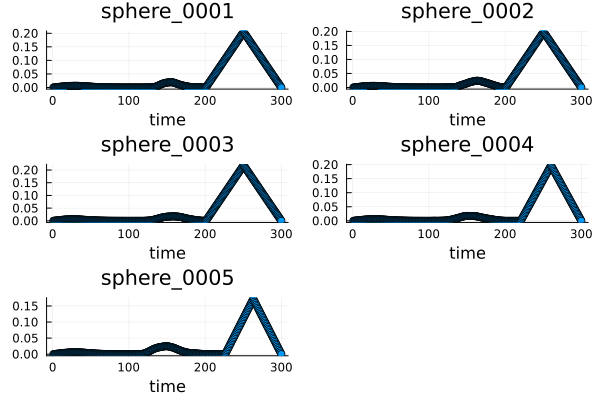

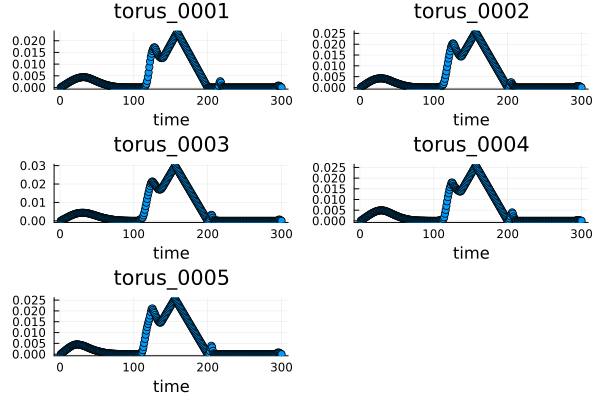

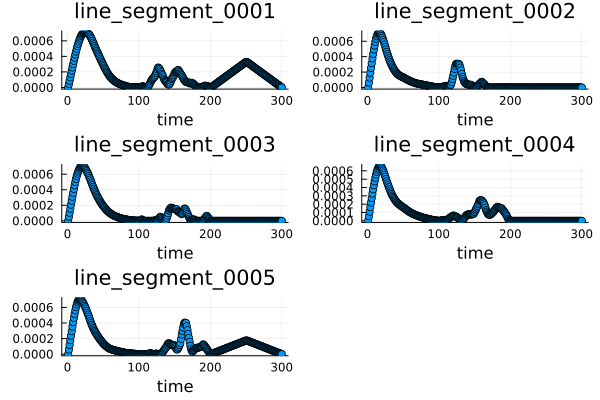

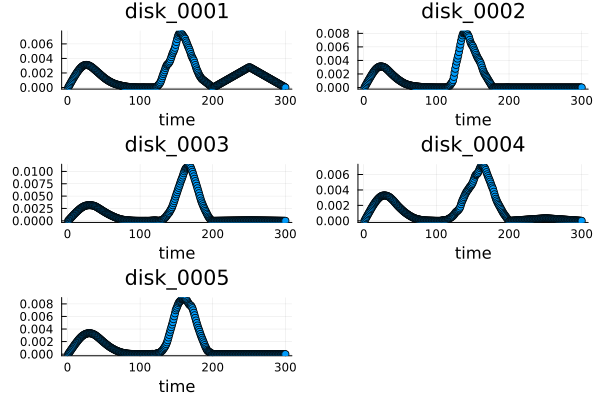

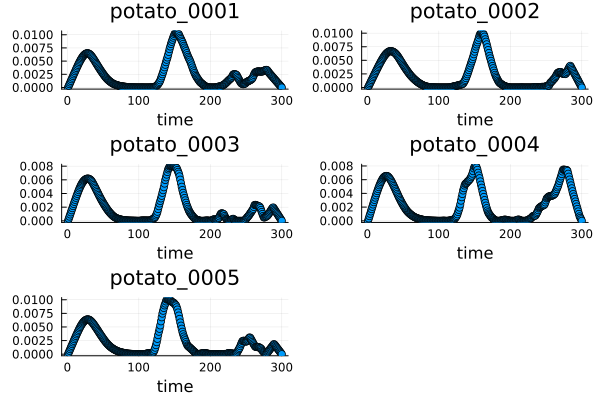

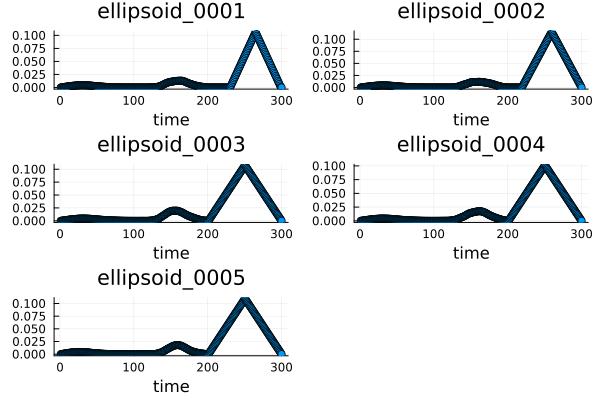

In [70]:
plots = []

for (i,sil) in enumerate(silhouettes) 
    ttl = corr_results[i]
    push!(plots,Visualization.plot_persistence_silhouette_approx(sil; ttl = ttl))
    if i%length(n_pershape) == 0
        display(plot(plots[(i-length(n_pershape)+1):i]..., layout = good_layout))
    end
end 

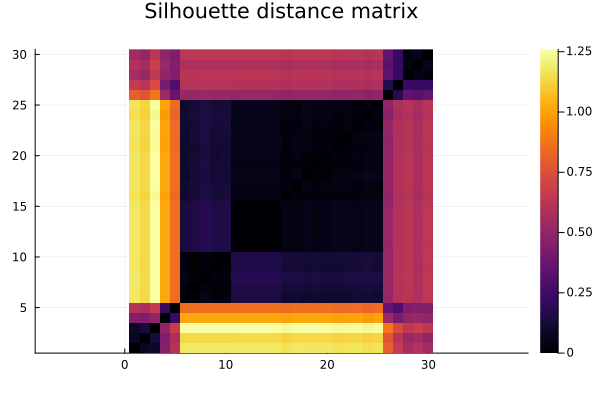

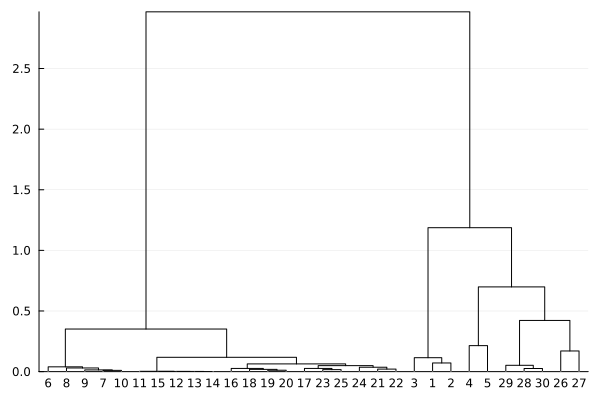

Cluster 1 ---------
Any["sphere_0001", "sphere_0002", "sphere_0003"]
Cluster 2 ---------
Any["sphere_0004", "sphere_0005"]
Cluster 3 ---------
Any["torus_0001", "torus_0002", "torus_0003", "torus_0004", "torus_0005"]
Cluster 4 ---------
Any["line_segment_0001", "line_segment_0002", "line_segment_0003", "line_segment_0004", "line_segment_0005", "disk_0001", "disk_0002", "disk_0003", "disk_0004", "disk_0005", "potato_0001", "potato_0002", "potato_0003", "potato_0004", "potato_0005"]
Cluster 5 ---------
Any["ellipsoid_0001", "ellipsoid_0002"]
Cluster 6 ---------
Any["ellipsoid_0003", "ellipsoid_0004", "ellipsoid_0005"]


In [71]:
# hirachical clustering 
normalize = false 

# prepare the data - normalization 
Xh = []
for sil in silhouettes
    if normalize 
        push!(Xh, sil ./ norm(sil))
    else 
        push!(Xh, sil)
    end 
end   

# create distance matrix 
D_sil = zeros(length(Xh), length(Xh))
for (i, sil) in enumerate(Xh) 
    for j in 1:i-1
        D_sil[i,j] = norm(sil - Xh[j])
        D_sil[j,i] = norm(sil - Xh[j])
    end 
end 

display(heatmap(D_sil, aspect_ratio=:equal, title="Silhouette distance matrix"))

# perform hirachical clustering 
results_hclustering_sil =  hclust(D_sil, linkage = :ward)
display(plot(results_hclustering_sil))

# get clusters
# k = number of clusters 
hclusters_sil = cutree(results_hclustering_sil; k = length(shapes))

# print results 
for c in 1:length(shapes)
    println("Cluster $c ---------")
    println(corr_results[hclusters_sil .== c])
end

In [72]:
# kmeans clustering 
normalize = true 

# prepare the data 
Xk = [Vector{Float64}(s) for s in silhouettes]
Xk = hcat(Xk...)
for i in 1:size(Xk)[2]
    # normalize each col
    if normalize && (norm(Xk[:,i]) != 0)
        Xk[:,i] = Xk[:,i] ./ norm(Xk[:,i])
    end 
end 

# perform kmeans clustering 
results_kclustering_sil = kmeans(Xk, length(shapes))

# get the clusters 
kclusters_sil = results_kclustering_sil.assignments

# print the results 
for c in 1:length(shapes)
    println("Cluster $c ---------")
    println(corr_results[kclusters_sil .== c])
end


Cluster 1 ---------
Any["torus_0001", "torus_0002", "torus_0003", "torus_0004", "torus_0005"]
Cluster 2 ---------
Any["line_segment_0002", "line_segment_0003", "line_segment_0004", "line_segment_0005"]
Cluster 3 ---------
Any["disk_0001", "disk_0003", "disk_0004", "disk_0005", "potato_0002"]
Cluster 4 ---------
Any["sphere_0001", "sphere_0002", "sphere_0003", "sphere_0004", "sphere_0005", "ellipsoid_0001", "ellipsoid_0002", "ellipsoid_0003", "ellipsoid_0004", "ellipsoid_0005"]
Cluster 5 ---------
Any["disk_0002", "potato_0001", "potato_0003", "potato_0004", "potato_0005"]
Cluster 6 ---------
Any["line_segment_0001"]


## Using KNN model for new prediction

In [79]:

function combine_distances(Ds::Vector{<:AbstractMatrix}, weights::AbstractVector{<:Real})
    @assert length(Ds) == length(weights)
    n = size(Ds[1], 1)
    D = zeros(Float64, n, n)
    for (hi, w) in enumerate(weights)
        @assert size(Ds[hi], 1) == n && size(Ds[hi], 2) == n
        D .+= w .* Ds[hi]
    end
    return D
end

function knn_predict_index(D::AbstractMatrix, labels::Vector{String}, i::Int; k::Int=5)
    n = size(D, 1)
    @assert length(labels) == n
    @assert 1 <= i <= n
    @assert k < n

    idxs = collect(1:n)
    deleteat!(idxs, i)            
    sorted = sort(idxs, by=j -> D[i,j])
    nn = sorted[1:k]

    counts = Dict{String, Int}()
    for j in nn
        counts[labels[j]] = get(counts, labels[j], 0) + 1
    end

    best_label = ""
    best_count = -1
    best_sumdist = Inf
    for (lab, c) in counts
        s = sum(D[i,j] for j in nn if labels[j] == lab)
        if (c > best_count) || (c == best_count && s < best_sumdist)
            best_label = lab
            best_count = c
            best_sumdist = s
        end
    end

    return best_label
end

function knn_leave_one_out(D::AbstractMatrix, labels::Vector{String}; k::Int=5)
    n = size(D, 1)
    correct = 0
    errors = Tuple{Int,String,String}[]
    for i in 1:n
        pred = knn_predict_index(D, labels, i; k=k)
        if pred == labels[i]
            correct += 1
        else
            push!(errors, (i, labels[i], pred))
        end
    end
    return correct/n, errors
end

knn_leave_one_out (generic function with 1 method)

In [ ]:
weights = [0.5, 3.0, 2.0]  
Dcomb = combine_distances(Ds, weights)

30×30 Matrix{Float64}:
  0.0       4.87793   4.93668   4.31288  …  12.0512   12.7523   12.2757
  4.87793   0.0       5.37903   4.05738     10.6173   11.4935   10.7503
  4.93668   5.37903   0.0       5.20417     13.1619   13.7088   13.1221
  4.31288   4.05738   5.20417   0.0         10.7285   11.5134   10.9715
  5.20938   4.19889   5.87619   4.56026     10.4946   11.36     10.8199
 13.965    12.6016   14.8794   12.4387   …   5.42594   5.69781   5.17871
 13.522    12.1425   14.339    12.1098       4.81982   4.80592   4.66906
 13.1586   11.7582   13.8617   11.7162       4.99528   5.07047   4.72765
 12.4184   11.2878   13.6108   10.9229       6.50892   6.88658   6.13809
 12.866    11.7529   13.8701   11.3159       5.8291    6.26718   5.98761
  ⋮                                      ⋱                      
 11.0858   12.2      13.3914   11.5638      12.1765   13.0667   12.101
  8.99854   9.50416  11.0456    9.09177      9.92571  10.4677    9.72064
  9.46472  10.3465   11.3445    9.96615    

In [83]:
acc, errors = knn_leave_one_out(Dcomb, String.(corr_results); k=5)
println("Accuracy = ", acc)
println("Nb errors = ", length(errors))
errors

Accuracy = 0.0
Nb errors = 30


30-element Vector{Tuple{Int64, String, String}}:
 (1, "sphere_0001", "sphere_0004")
 (2, "sphere_0002", "sphere_0004")
 (3, "sphere_0003", "sphere_0001")
 (4, "sphere_0004", "sphere_0002")
 (5, "sphere_0005", "sphere_0002")
 (6, "torus_0001", "torus_0002")
 (7, "torus_0002", "torus_0003")
 (8, "torus_0003", "torus_0002")
 (9, "torus_0004", "torus_0005")
 (10, "torus_0005", "torus_0004")
 ⋮
 (22, "potato_0002", "potato_0001")
 (23, "potato_0003", "potato_0005")
 (24, "potato_0004", "potato_0005")
 (25, "potato_0005", "potato_0004")
 (26, "ellipsoid_0001", "ellipsoid_0003")
 (27, "ellipsoid_0002", "ellipsoid_0005")
 (28, "ellipsoid_0003", "ellipsoid_0001")
 (29, "ellipsoid_0004", "ellipsoid_0005")
 (30, "ellipsoid_0005", "ellipsoid_0004")

# additional ideas ... (not presented)

In [ ]:
# hirachical clustering on the seperate silhuettes 

# create distance matrix
D_sil_3 = zeros(length(silhouettes_separatly), length(silhouettes_separatly))
for (i, sil_i) in enumerate(silhouettes_separatly) 
    for j in 1:i-1
        sil_j = silhouettes_separatly[j]
        v = [abs.(sil_i[hi] .- sil_j[hi])  for hi in 1:length(sil_i)]
        d = maximum(maximum(reduce(vcat, permutedims.(v)), dims = 1))
        D_sil_3[i,j] = d
        D_sil_3[j,i] = d
    end 
end

display(heatmap(D_sil_3, aspect_ratio=:equal, title="Silhouette distance matrix"))

# perform hirachical clustering 
results_hclustering_sil_3 =  hclust(D_sil_3, linkage = :ward)
display(plot(results_hclustering_sil_3))

# get clusters
# k = number of clusters 
hclusters_sil_3 = cutree(results_hclustering_sil_3; k = length(shapes))

# print results 
for c in 1:length(shapes)
    println("Cluster $c ---------")
    println(corr_results[hclusters_sil_3 .== c])
end